<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science with Generative AI: Applications to Business</font></center>
<center><font size=6>Robust Data Modeling with Ensembling and Tuning Techniques</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    make_scorer
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
import warnings

# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EasyVisa.csv')
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


# **Overview of the Dataset**

* Observations

* Sanity checks

In [5]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [6]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000,25480.000,25480.000
mean,5667.043,1979.410,74455.815
std,22877.929,42.367,52815.942
min,-26.000,1800.000,2.137
25%,1022.000,1976.000,34015.480
50%,2109.000,1997.000,70308.210
75%,3504.000,2005.000,107735.513
max,602069.000,2016.000,319210.270


In [7]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [10]:
df.shape

(25480, 12)

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [11]:
# num of employees has a negative value, needs to be fixed using absolute value
print(df.loc[df["no_of_employees"] < 0].shape)
df["no_of_employees"] = abs(df["no_of_employees"])

(33, 12)


In [12]:
df.loc[df["no_of_employees"] < 0].shape

(0, 12)

In [13]:
#Checking the id column to see if its needed
df["case_id"].nunique()

25480

* Since the id column has exactly the same amount of unique values as number of rows in the data then we can just drop it

In [14]:
df.drop("case_id", axis=1, inplace=True)

In [15]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


Univariate Analysis

In [16]:
def boxhistplot(data,column):
  fig, axes = plt.subplots(2, 1, figsize=(15, 5))
  sns.boxplot(data=data, x=column, ax=axes[0])
  sns.histplot(data=data, x=column, ax=axes[1])
  plt.tight_layout()
  plt.show()

In [17]:
def perccountplot(data, column, target):
    total = len(data[column])
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=data, x=column, order=data[column].value_counts().index,hue=target)

    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

    plt.title(f'Count Plot of {column} with Percentages')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

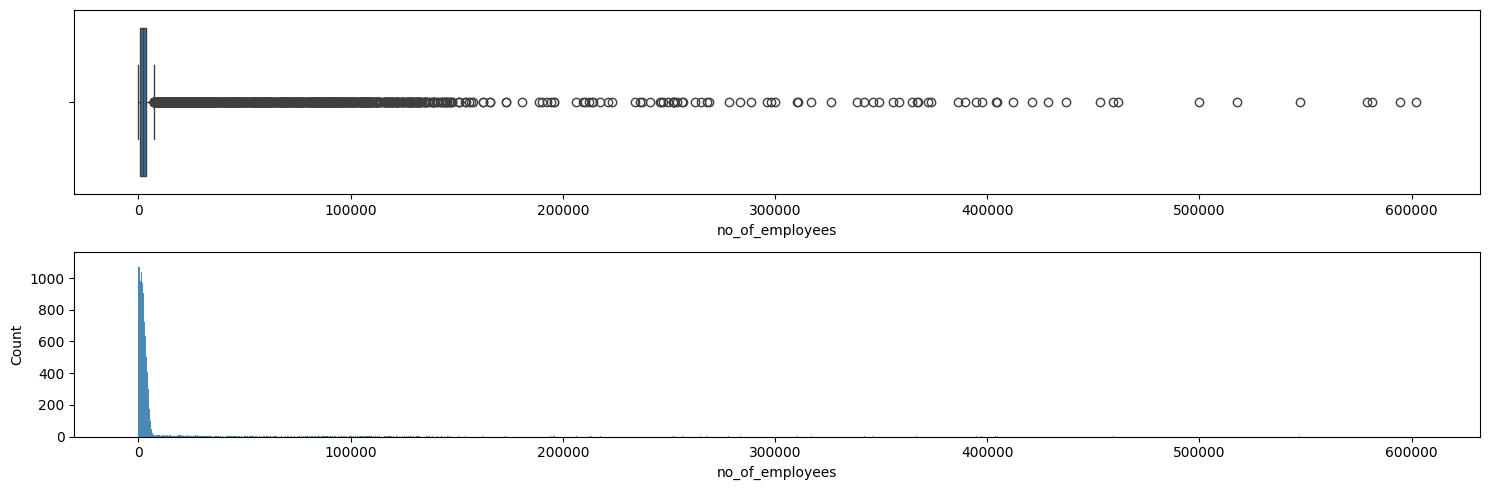

In [18]:
boxhistplot(df, "no_of_employees")

* Extreme outliers, heavily right skewed and an average number of employees around 5000
* 75% of companies have less than 7000 employees

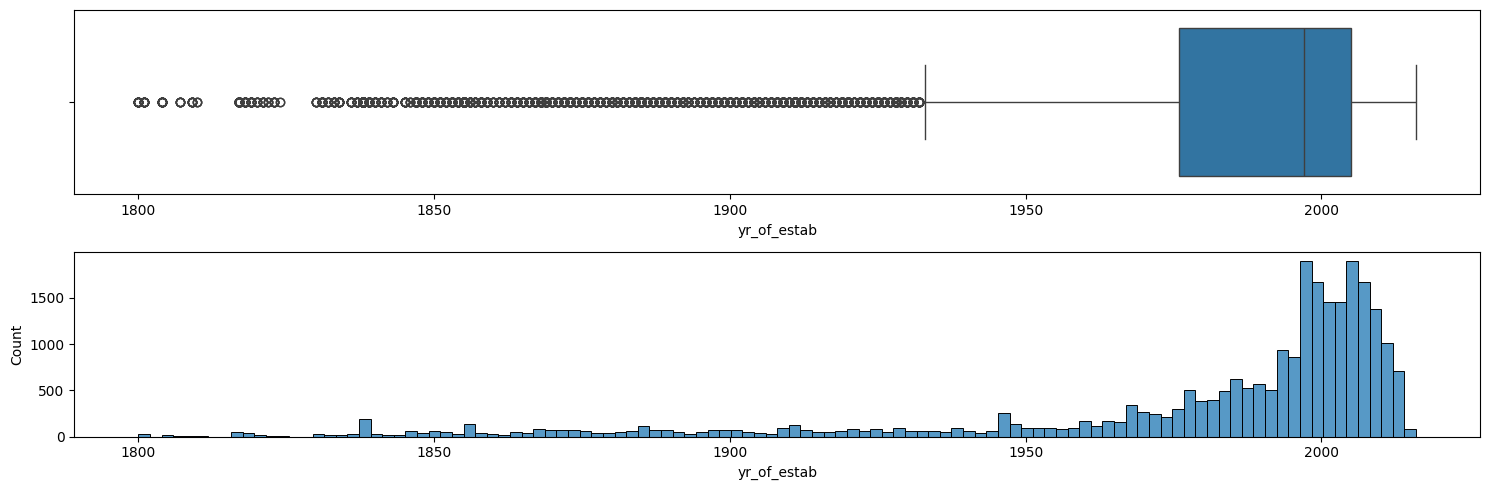

In [19]:
boxhistplot(df,"yr_of_estab")

* Left skewed graph, avg year of establishment around the 1990s
* 75% of companies weren't established past the 2000s
* Lots of outliers in before the 1930s

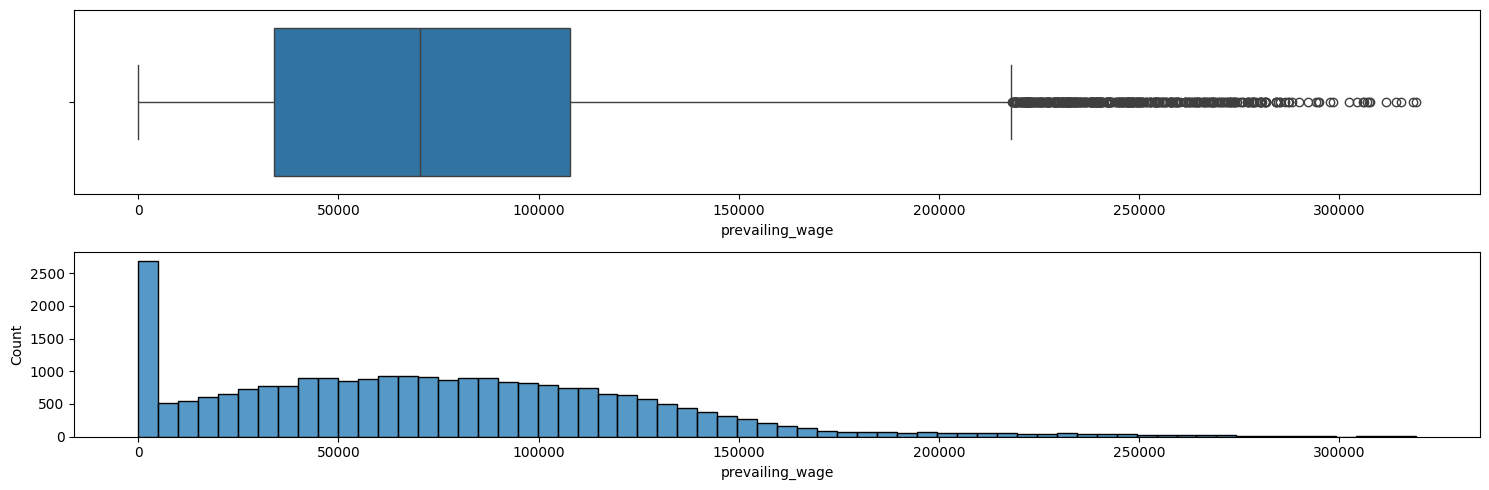

In [20]:
boxhistplot(df, "prevailing_wage")

* Graph would be normally distrubuted except for the very high count of lower prevailing wages
* Avg pre wage is arounf $70,000 with 75% of them being under $120,000
* Outliers exceed $225,000

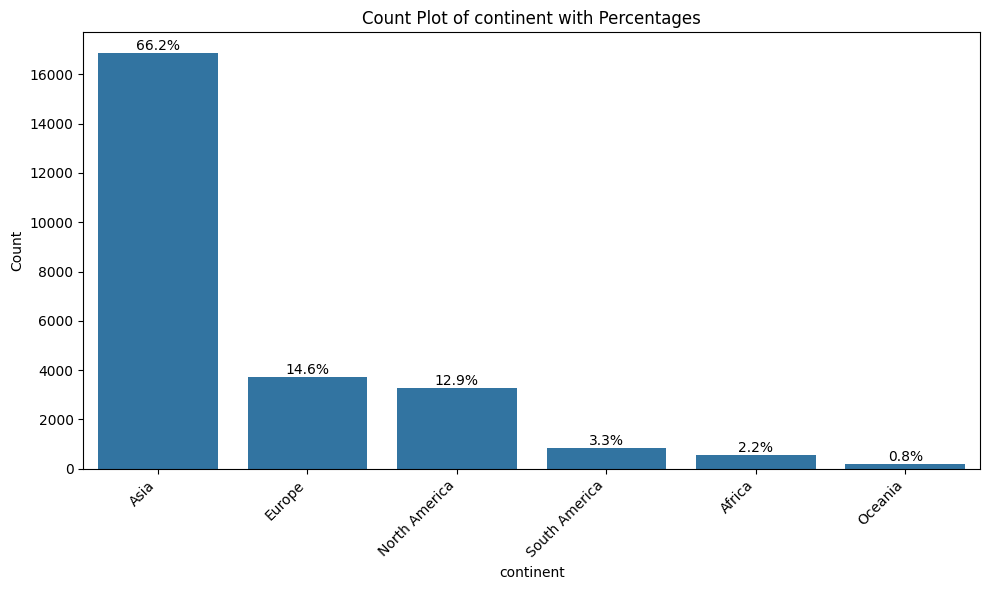

In [21]:
perccountplot(df,'continent',target=None)

* Asia is where most visa applicants are from

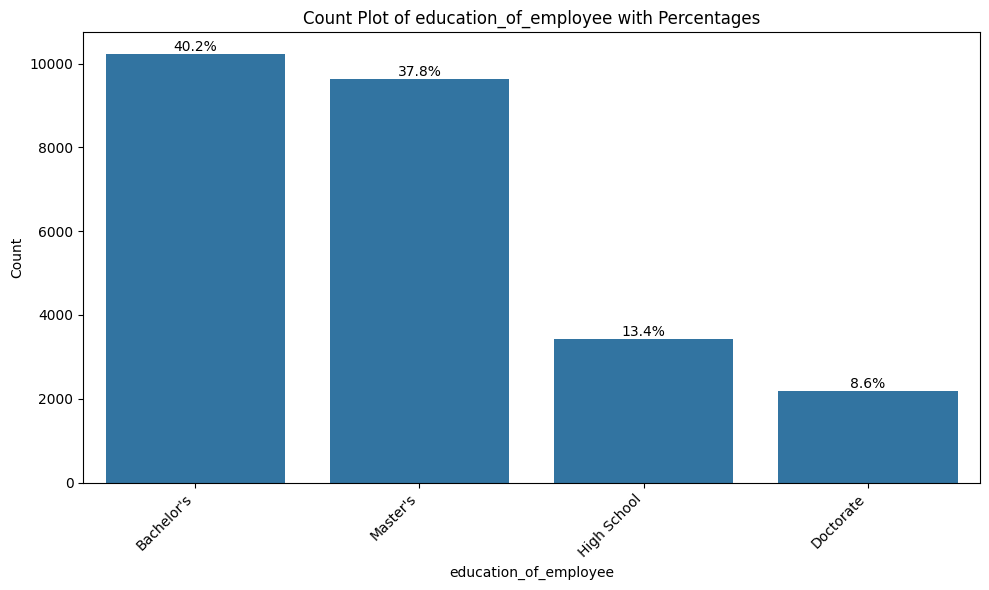

In [22]:
perccountplot(df,'education_of_employee',target=None)

* Over 75% of visa applicants have either a bachelor's or master's degree

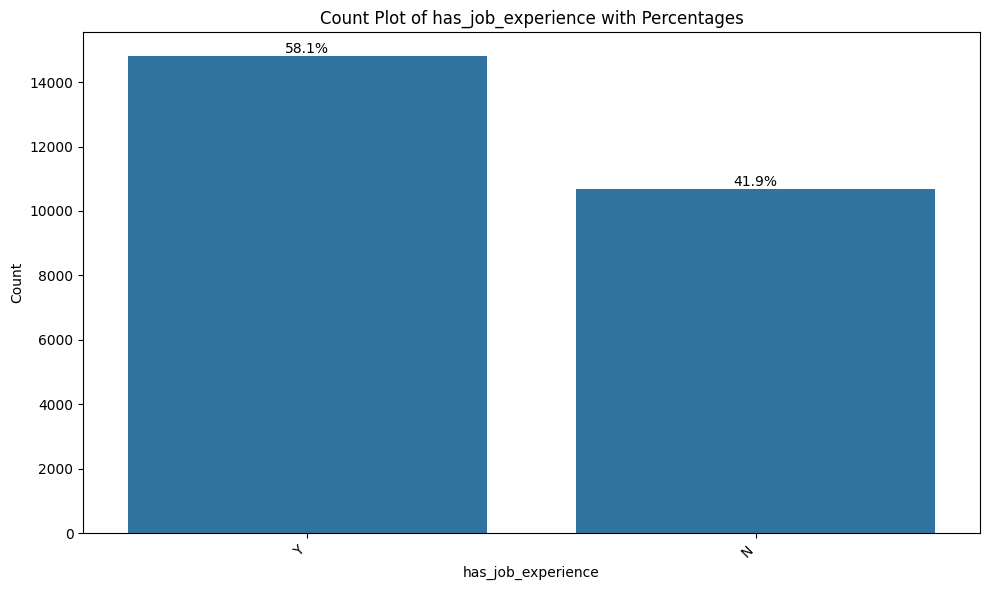

In [23]:
perccountplot(df,'has_job_experience',target=None)

* 41% of applicants do not have job experience

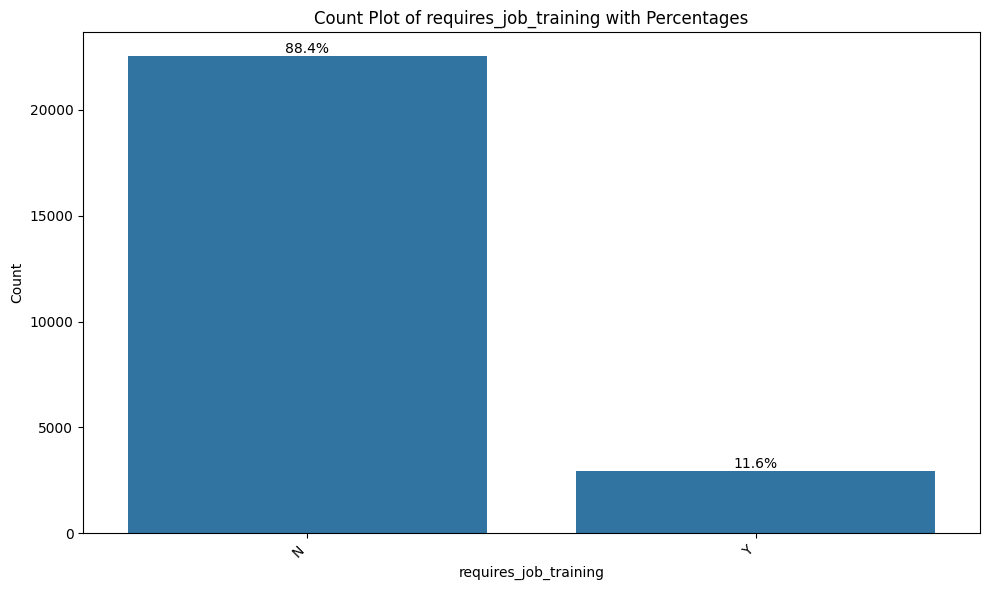

In [24]:
perccountplot(df,'requires_job_training',target=None)

* So even though 41% of applicants have no job experience, almost 90% of all appliacnts don't need job training

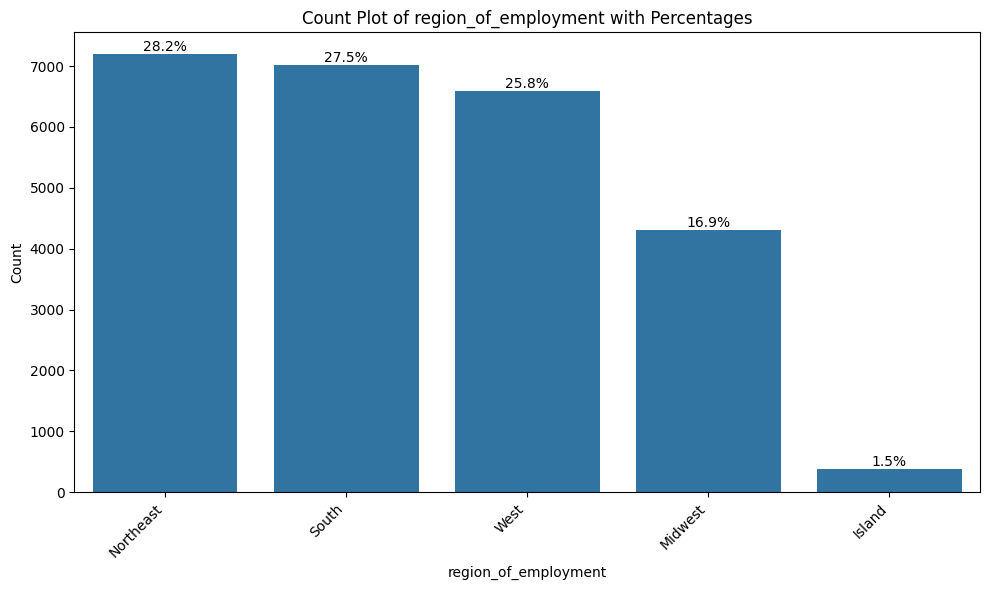

In [25]:
perccountplot(df,'region_of_employment',target=None)

* All region values are similar except island which makes sense since islands make up a very small percentage of land on the Earth

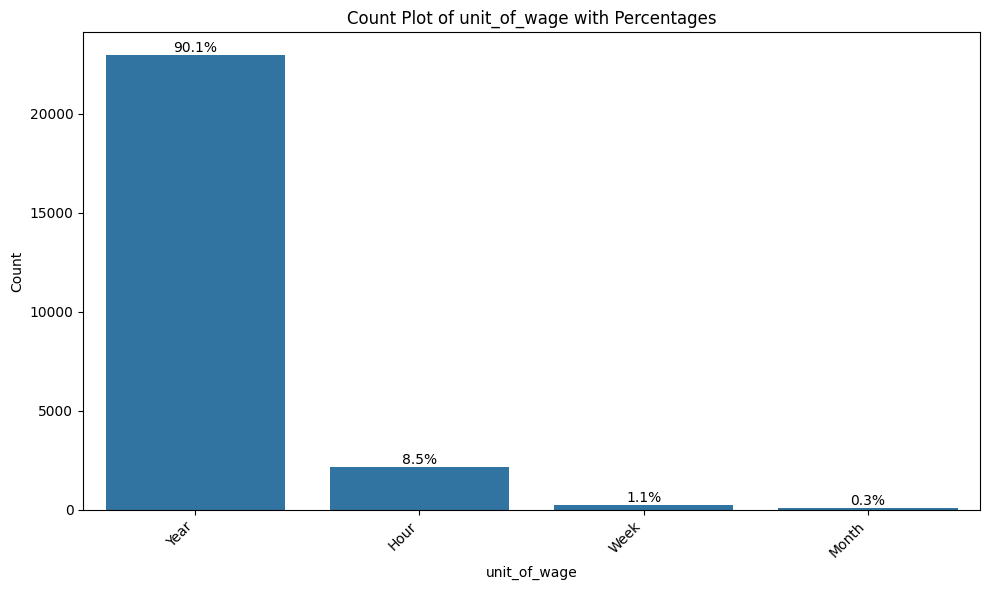

In [26]:
perccountplot(df,'unit_of_wage',target=None)

* Most applicants have a yearly wage or a salary

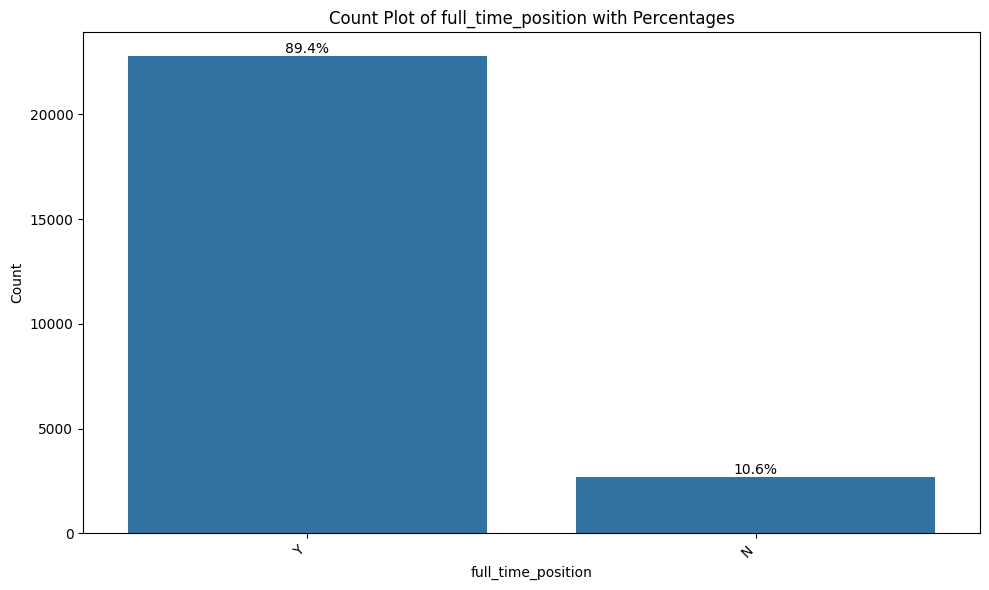

In [27]:
perccountplot(df,'full_time_position',target=None)

* Majority of applicants have full time positions

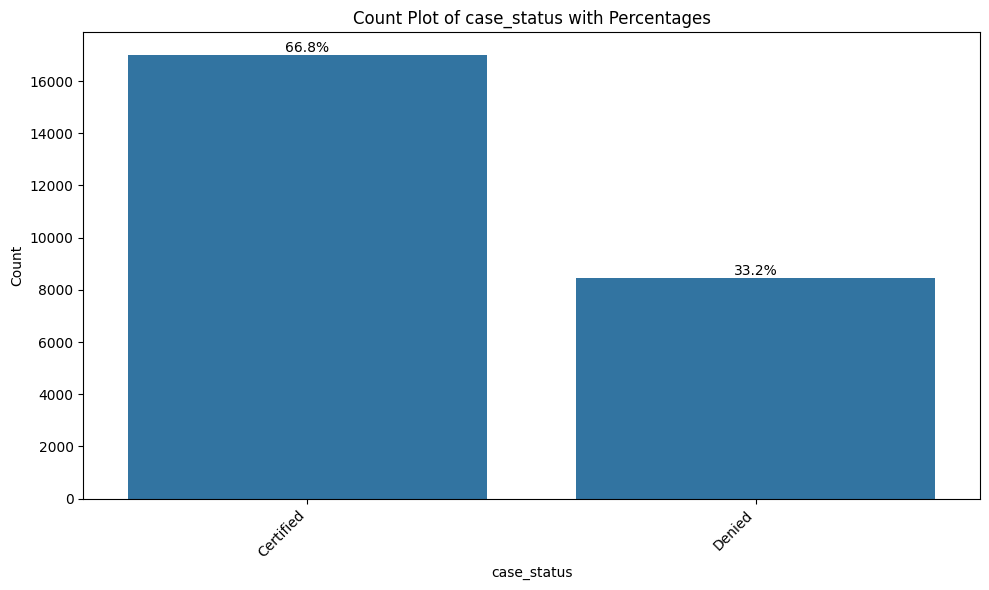

In [28]:
perccountplot(df,'case_status',target=None)

* Around 2/3rds of applicants get their visa applications accepted

Bivariate Analysis

<Axes: xlabel='education_of_employee', ylabel='count'>

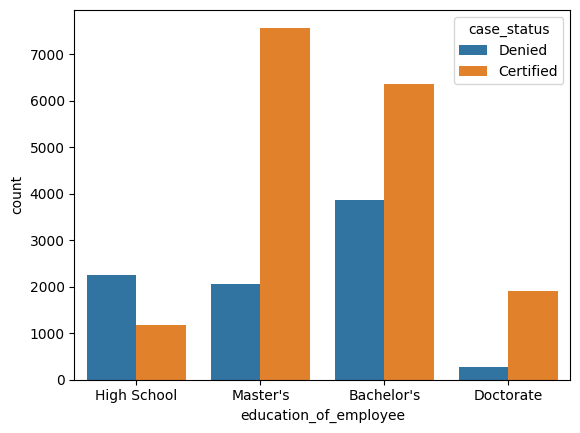

In [29]:
sns.countplot(data=df, x="education_of_employee", hue="case_status")

* Masters degrees have the highest number with bachelors being a close second
* Though people with a doctorate have a similar acceptance rate to a masters degree

<Axes: xlabel='has_job_experience', ylabel='count'>

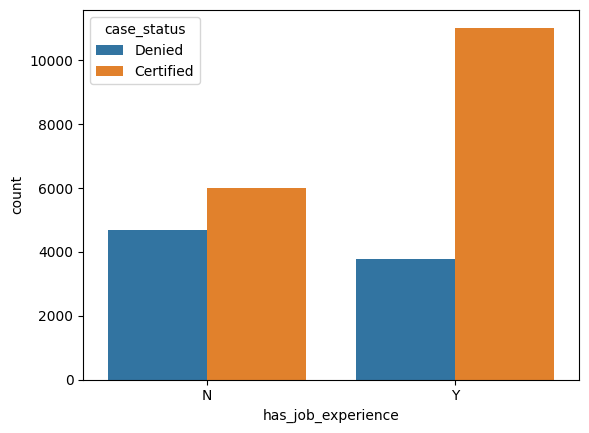

In [30]:
sns.countplot(data=df, x="has_job_experience", hue="case_status")

* Applicants are more likely to be accepted if they have previous job experience

/tmp/ipykernel_1614/715078406.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="prevailing_wage", y="case_status",palette = 'BuPu')


<Axes: xlabel='prevailing_wage', ylabel='case_status'>

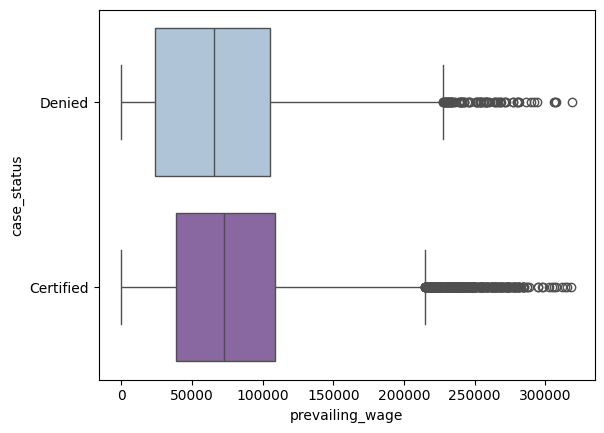

In [31]:
sns.boxplot(data=df, x="prevailing_wage", y="case_status",palette = 'BuPu')

* Prevailing wages are similar between case status'. So no, prevailing wage doesn't determine whether an applicant is accepted.

<Axes: xlabel='region_of_employment', ylabel='count'>

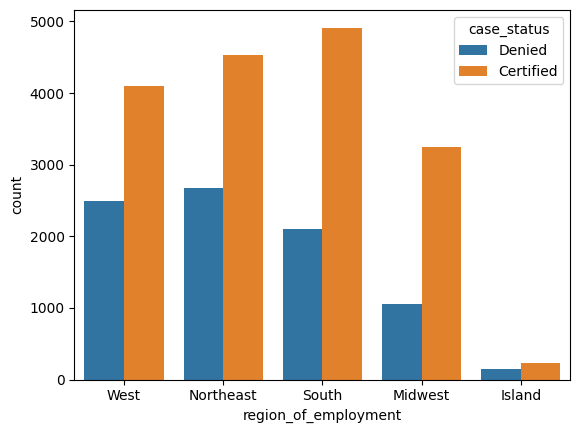

In [32]:
sns.countplot(data=df, x="region_of_employment", hue="case_status")

* People from a southern region seem to have slightly more accepted applicants than other regions but no significant differences except for island regions which is reasonable

/tmp/ipykernel_1614/1279339573.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="no_of_employees", y="case_status",palette = 'BuPu')


<Axes: xlabel='no_of_employees', ylabel='case_status'>

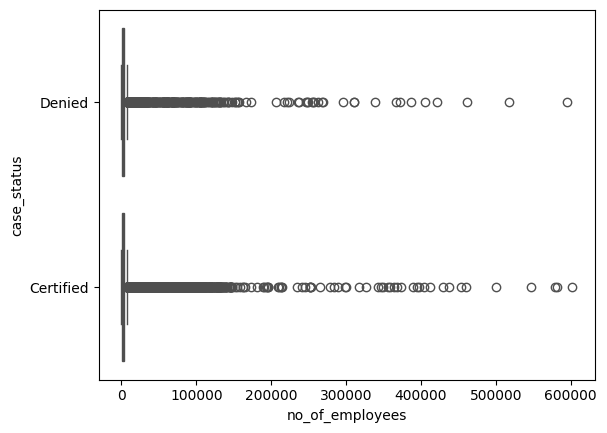

In [33]:
sns.boxplot(data=df, x="no_of_employees", y="case_status",palette = 'BuPu')

* Acceptance rate and denied rate are very similar, so number of employees doesn't dictate acceptance rate
* Companies with a higher number of employees have a slightly higher acceptance rate

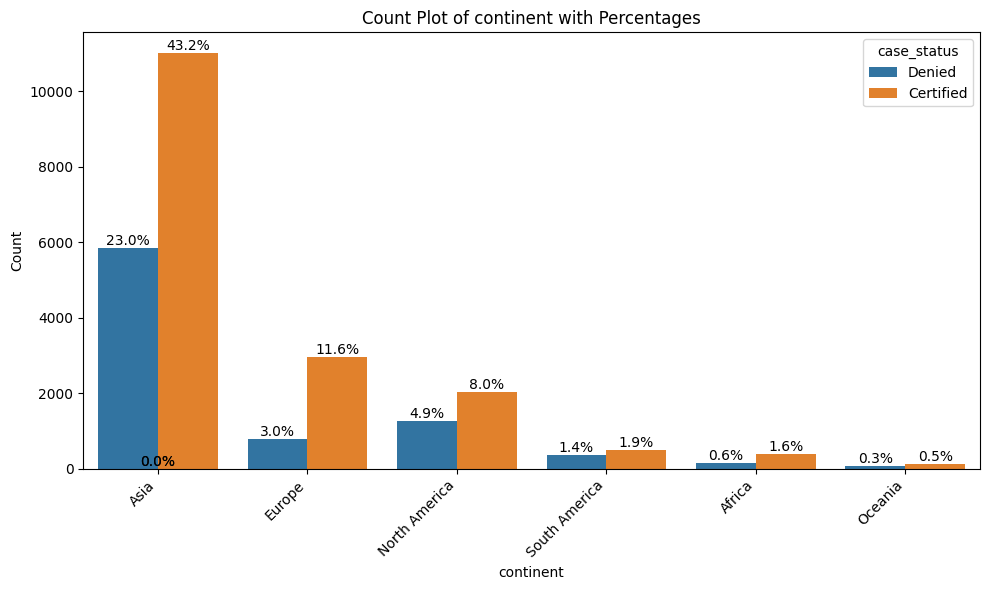

In [34]:
perccountplot(df,"continent", "case_status")

* Europe has the highest approval rate, asia has the most applicants, and south america has the lowest apporval

/tmp/ipykernel_1614/640458757.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="yr_of_estab", y="case_status",palette = 'BuPu')


<Axes: xlabel='yr_of_estab', ylabel='case_status'>

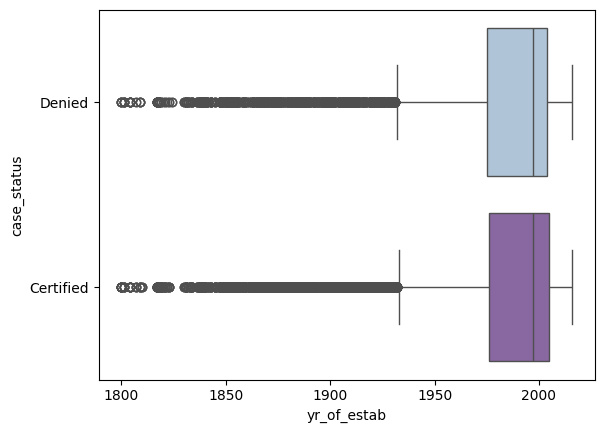

In [35]:
sns.boxplot(data=df, x="yr_of_estab", y="case_status",palette = 'BuPu')

* Year the company was made does not effect acceptance of application

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [36]:
# Outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}': {len(outliers)} outliers found.")
    # Display some of the outliers if needed
    # if not outliers.empty:
    #     display(outliers[[col]].head())

Column 'no_of_employees': 1556 outliers found.
Column 'yr_of_estab': 3260 outliers found.
Column 'prevailing_wage': 427 outliers found.


In [37]:
# Prepare Data for Modeling
# Converting status variable to numerical values
df["case_status"] = df["case_status"].replace({"Certified":1,"Denied":0})

X = df.drop(["case_status"], axis=1)
y = df["case_status"]

X = pd.get_dummies(X, drop_first=True)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

/tmp/ipykernel_1614/2771041283.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["case_status"] = df["case_status"].replace({"Certified":1,"Denied":0})


# **Model Building**

* Going to choose f1 score as metric to hone in on because both wrong cases of prediction (Predicting someone as certified when should've been denied and prediciting someone as denied when should've been certified) are of equal importance.

In [38]:
def metrics(model, predictors, target):

    pred_temp = model.predict(predictors)
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [39]:
def matrix(model, predictors, target):

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Original Data Model

In [40]:
models = []

# Appending models into list models
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.989150179193873
Random Forest: 1.0
Decision Tree: 1.0
AdaBoost: 0.8204269947530306
Gradient Boosting: 0.8291218182658106
XGBoost: 0.8949354703443134

Validation Performance:

Bagging: 0.7736516357206012
Random Forest: 0.8049978941457251
Decision Tree: 0.7434385137127691
AdaBoost: 0.8180081855388813
Gradient Boosting: 0.826637008202419
XGBoost: 0.8136160714285714


* Gradient Boosting and Adaboost have least amount of difference between f1_scores

Over Sampled Data Model

In [41]:
#Creating the over sampled data
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [42]:
models = []

# Appending models into list models
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9875473741201949
Random Forest: 0.9999510260051913
Decision Tree: 1.0
AdaBoost: 0.8005498403689252
Gradient Boosting: 0.8072434234901815
XGBoost: 0.875279433681073

Validation Performance:

Bagging: 0.7665171898355755
Random Forest: 0.7965442764578834
Decision Tree: 0.7320006012325266
AdaBoost: 0.8195334879279771
Gradient Boosting: 0.8173049645390071
XGBoost: 0.8098591549295775


* Gradient Boost and Adaboost have least amount of difference between f1_scores
* XGBoost scores are closer than the other two models and I want to try XGBoost since parameters are very flexible

Under Sampled Data model

In [43]:
rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [44]:
models = []

# Appending models into list models
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores = f1_score(y_train_under, model.predict(X_train_under))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")
for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9803687095166915
Random Forest: 1.0
Decision Tree: 1.0
AdaBoost: 0.7015343047380103
Gradient Boosting: 0.7281441717791411
XGBoost: 0.8760975609756098

Validation Performance:

Bagging: 0.7057046979865772
Random Forest: 0.7417218543046358
Decision Tree: 0.6955818093542644
AdaBoost: 0.765990884802766
Gradient Boosting: 0.776595744680851
XGBoost: 0.7557251908396947


* Gradient Boost has least difference between f1_scores, but there are better models to choose from

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


* The models I have chosen to move forward with tuning are the Oversampled XGBoost model, the Original Gradient Boost model, and the Original Adaboost model

In [45]:
#AdaBoost Tuned Model on the Original data
adatune= AdaBoostClassifier(random_state=1)

param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

acc_scorer = make_scorer(f1_score)
rand_obj = RandomizedSearchCV(estimator=adatune,param_distributions=param_grid,n_iter=15,scoring=acc_scorer,cv=5,n_jobs=-1)
rand_obj = rand_obj.fit(X_train, y_train)

adatune = rand_obj.best_estimator_

adatune.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.05, n_estimators=np.int64(100),
                   random_state=1)

In [46]:
ada1=metrics(adatune, X_train, y_train)
ada1

,Accuracy,Recall,Precision,F1
0,0.749,0.874,0.778,0.823


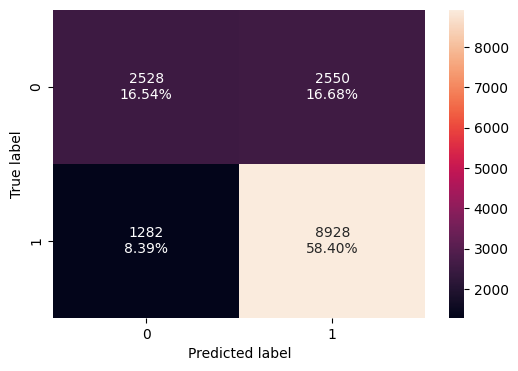

In [47]:
matrix(adatune, X_train, y_train)

In [48]:
ada2=metrics(adatune, X_val, y_val)
ada2

,Accuracy,Recall,Precision,F1
0,0.751,0.870,0.782,0.824


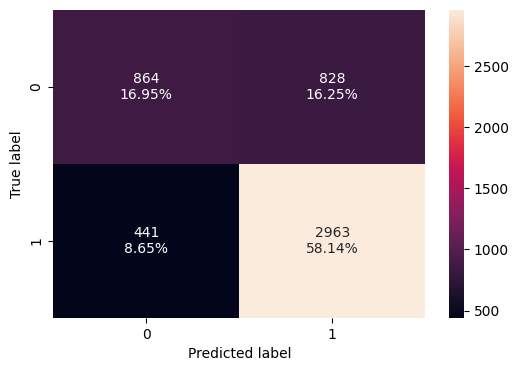

In [49]:
matrix(adatune, X_val, y_val)

* F1 score is high and no overfitting is occuring

In [50]:
#Gradient Boost Tuned Model on the Original data
gbtune= GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1), random_state=1)

param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

acc_scorer = make_scorer(f1_score)
rand_obj = RandomizedSearchCV(estimator=gbtune,param_distributions=param_grid,n_iter=15,scoring=acc_scorer,cv=5,n_jobs=-1)
rand_obj = rand_obj.fit(X_train, y_train)

gbtune = rand_obj.best_estimator_

gbtune.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=np.int64(50), random_state=1,
                           subsample=0.7)

In [51]:
gb1=metrics(gbtune, X_train, y_train)
gb1

,Accuracy,Recall,Precision,F1
0,0.750,0.899,0.767,0.828


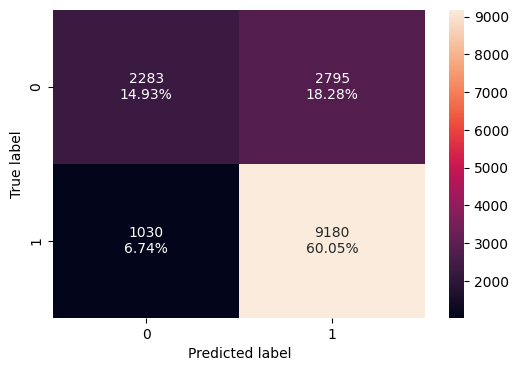

In [52]:
matrix(gbtune, X_train, y_train)

In [53]:
gb2 = metrics(gbtune, X_val, y_val)
gb2

,Accuracy,Recall,Precision,F1
0,0.749,0.897,0.767,0.827


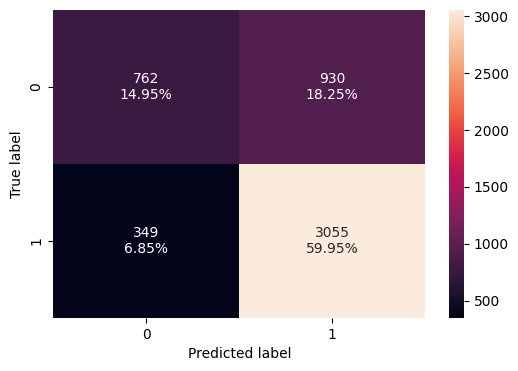

In [54]:
matrix(gbtune, X_val, y_val)

* F1 score is higher than adaboost and no overfitting is occuring

In [55]:
#XGBoost Model on the Oversampled data
xgbtune= XGBClassifier(random_state=1)

param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

acc_scorer = make_scorer(f1_score)
rand_obj = RandomizedSearchCV(estimator=xgbtune,param_distributions=param_grid,n_iter=20,scoring=acc_scorer,cv=5,n_jobs=-1)
rand_obj = rand_obj.fit(X_train_over, y_train_over)

xgbtune = rand_obj.best_estimator_

xgbtune.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(100), n_jobs=None, num_parallel_tree=None, ...)

In [56]:
xgb1 = metrics(xgbtune, X_train, y_train)
xgb1

,Accuracy,Recall,Precision,F1
0,0.743,0.949,0.740,0.831


In [57]:
xgb2 = metrics(xgbtune, X_val, y_val)
xgb2

,Accuracy,Recall,Precision,F1
0,0.730,0.939,0.732,0.823


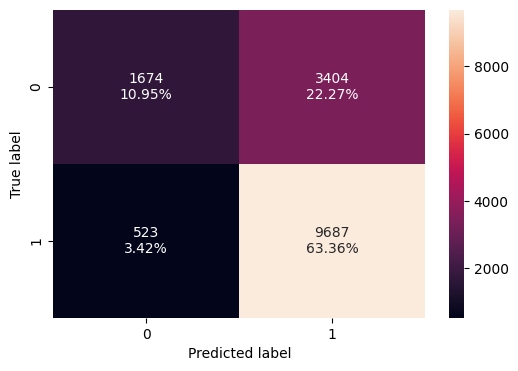

In [58]:
matrix(xgbtune, X_train, y_train)

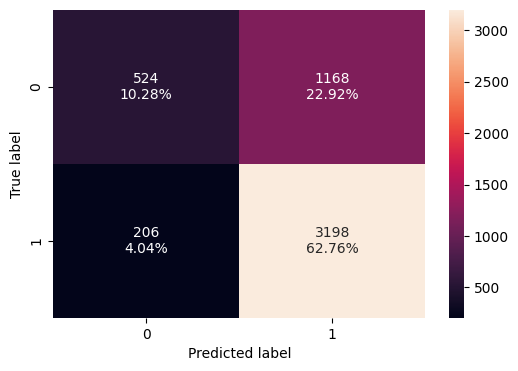

In [59]:
matrix(xgbtune, X_val, y_val)

* F1 score is the highest out of all models and no overfitting is occuring

# **Model Comparison and Final Model Selection**

In [60]:
# training performance comparison

traincomp = pd.concat([ada1.T, gb1.T, xgb1.T,],axis=1)
traincomp.columns = ["Tuned Adaboost","Tuned Gradient Boost","Tuned XGBoost",]
traincomp

,Tuned Adaboost,Tuned Gradient Boost,Tuned XGBoost
Accuracy,0.749,0.750,0.743
Recall,0.874,0.899,0.949
Precision,0.778,0.767,0.740
F1,0.823,0.828,0.831


In [61]:
# validation performance comparison

valcomp = pd.concat([ada2.T, gb2.T, xgb2.T,],axis=1)
valcomp.columns = ["Tuned Adaboost","Tuned Gradient Boost","Tuned XGBoost",]
valcomp

,Tuned Adaboost,Tuned Gradient Boost,Tuned XGBoost
Accuracy,0.751,0.749,0.730
Recall,0.870,0.897,0.939
Precision,0.782,0.767,0.732
F1,0.824,0.827,0.823


* Xgboost tuned model from the oversampled data has the best f1 score of other tuned models
* Eventhough the difference in f1 scores between models is pretty small, xgboost still comes out on top; therefore that is the best model

In [62]:
metrics(xgbtune, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.720,0.938,0.725,0.818


* F1 score is still high but around 0.007 down from validation set which isn't too signifcant

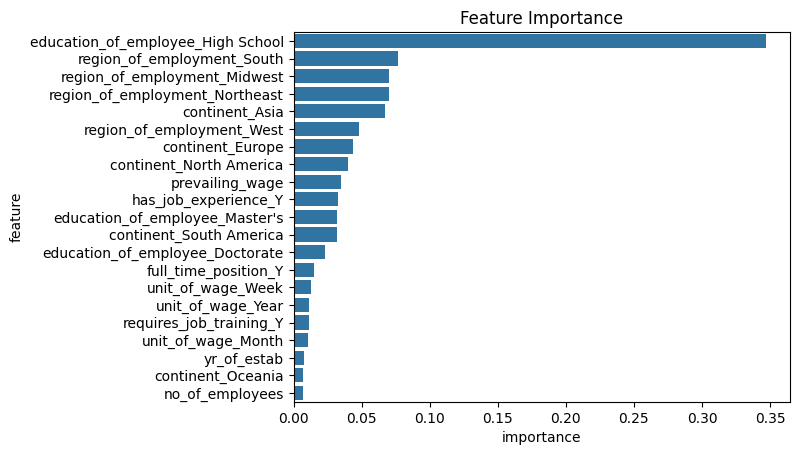

In [63]:
#Checking feature importance
imporfeat = pd.DataFrame(
    {'feature': X_train_over.columns,
     'importance': xgbtune.feature_importances_}
).sort_values('importance', ascending=False)
sns.barplot(x='importance', y='feature', data=imporfeat)
plt.title('Feature Importance')
plt.show()

* High school education is the most important feature with job experience and masters education coming after

# **Actionable Insights and Recommendations**



1.  **Visa Approval Rate:** Approximately two-thirds of visa applications are certified, while one-third are denied, indicating a significant portion of rejections.
2.  **Educational Background is Crucial:**
    *   Applicants with higher education levels (Master's and Doctorate degrees) show a higher propensity for visa certification compared to those with High School education.
    *   `education_of_employee_High School` is the most significant negative feature, while `education_of_employee_Master's` and `education_of_employee_Doctorate` are important positive indicators.
3.  **Job Experience is a Strong Driver:** Applicants with prior job experience (`has_job_experience_Y`) are significantly more likely to have their visas certified.
4.  **Geographical Differences Exist:**
    *   Asia accounts for the largest share of applicants, but Europe has the highest visa approval rate.
    *   South America has the lowest approval rate.
    *   Region of employment (e.g., Northeast, South, Midwest, West) shows some variation in approval rates, but less impact than education or experience.
5.  **Prevailing Wage Impact:** While the prevailing wage is a factor, the distribution of wages is similar for both certified and denied cases, suggesting it might not be the primary differentiating factor. Its importance in the model is moderate.
6.  **Full-time Positions and Wage Unit:** A large majority of applicants are for full-time positions, and 'Year' is the most common unit of wage. Both `full_time_position_Y` and `unit_of_wage_Year` contribute to the model's prediction, indicating stability in employment terms is valued.
7.  **Less Influential Factors:** The number of employees in a company (`no_of_employees`) and the year of establishment (`yr_of_estab`) appear to have minimal direct impact on visa approval. Similarly, whether an employee requires job training (`requires_job_training_Y`) has very low predictive power.
8.  **Model Performance:** The tuned XGBoost model achieved a good F1-score of approximately 0.82 on unseen test data, demonstrating its effectiveness in predicting visa outcomes with a good balance of precision and recall.

### Business Recommendations for EasyVisa and OFLC

1.  **Optimize Candidate Sourcing & Employer Matching (EasyVisa):**
    *   **Prioritize Profiles:** EasyVisa should advise employers to prioritize candidates with higher educational qualifications (Master's, Doctorate) and demonstrable job experience, as these are the strongest positive indicators for visa approval.
    *   **Targeted Recruitment:** When sourcing candidates, EasyVisa can strategically focus recruitment efforts on regions and continents with historically higher approval rates, such as Europe, while still catering to the large Asian applicant base with tailored guidance.

2.  **Streamline Application Processing (OFLC & EasyVisa):**
    *   **Automated Pre-screening:** The developed XGBoost model can be integrated into the OFLC's system for an initial pre-screening phase. Applications predicted with a high probability of certification could be fast-tracked, while those with a low probability could be flagged for closer manual review, saving time and resources.
    *   **Data-Driven Documentation:** EasyVisa can guide applicants to highlight their educational qualifications, job experience, and the full-time, salaried nature of their prospective roles, as these features are highly influential in the model.

3.  **Policy Review and Applicant Guidance (OFLC & EasyVisa):**
    *   **Policy Analysis:** OFLC could further analyze why 'High School' education is such a strong negative predictor and if current policies inadvertently disadvantage this group. If the goal is to expand the talent pool, this might be an area for policy revision or specific programs.
    *   **Improvement Roadmaps:** For applicants with profiles that currently have a lower chance of approval (e.g., limited job experience or lower education), EasyVisa can offer guidance on how to strengthen their applications, such as pursuing additional certifications or gaining relevant work experience before applying.

4.  **Focus on High-Impact Features:**
    *   Instead of investing resources into factors like the age of the company or the exact number of employees (which have low predictive power), both EasyVisa and OFLC should focus their efforts and documentation requirements on the highly influential features: education, job experience, continent of origin, and job type (full-time, yearly wage).
    

___